<a href="https://colab.research.google.com/github/adinmusababa/segmentasi/blob/main/notebooks/deeplabv3_binary_leaf_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepLabV3+ Binary Leaf Segmentation - Eksperimen Colab

Notebook eksperimen **DeepLabV3+** untuk segmentasi biner daun (`0` = background,
`1` = leaf). Model ini adalah **model kedua untuk ensemble dengan U-Net standar**
yang sudah dilatih di notebook referensi
`Unet_Binary_Leaf_Segmentation.ipynb`.

Seluruh logika inti memakai **base code repo ini** (`models/`, `losses/`,
`utils/`, `data_generators/`), disusun dalam sel notebook agar fleksibel
diubah untuk berbagai eksperimen.

**Kontrak kontinuitas dengan pipeline U-Net** (wajib dipertahankan):

| Komponen | Nilai |
|---|---|
| Input | RGB, resize 256 x 256 (BICUBIC) |
| Label | biner 0/1, konversi `mask != 0`, resize NEAREST |
| Output model | 2 channel logit `(B, 2, H, W)` |
| Probabilitas daun | `softmax(logits, dim=1)[:, 1]` -> resize ke ukuran asli (bilinear) |
| Split | `splits/{train,val,test}.txt` identik dengan U-Net |
| Checkpoint terbaik | Dice foreground tertinggi di **validation set** |

Alur: setup -> dataset -> split -> konfigurasi -> sanity check -> training
(early stopping) -> kurva pembelajaran -> evaluasi test -> visualisasi ->
ekspor artefak ensemble.

Catatan: artefak bersifat sementara di runtime Colab. Unduh folder
`ensemble_ready/` sebelum runtime di-reset jika ingin disimpan.

## 0. Setup Environment

Deteksi lingkungan lalu gunakan kode dari repo:
- **Colab**: clone repo (pastikan commit terbaru sudah di-push).
- **Lokal**: pakai repo yang sedang dibuka.

In [2]:
import os, sys, shutil, subprocess
from pathlib import Path

import torch
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

REPO_URL = 'https://github.com/adinmusababa/segmentasi.git'
REPO_BRANCH = 'setup'
REPO_DIR_NAME = 'deeplabV3-PyTorch'

IN_COLAB = 'google.colab' in sys.modules
print('Environment:', 'Colab' if IN_COLAB else 'Local')

if IN_COLAB:
    REPO_DIR = Path('/content') / REPO_DIR_NAME
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    subprocess.run(['git', 'clone', '-b', REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)
else:
    REPO_DIR = Path.cwd()
    while not (REPO_DIR / 'models').exists() and REPO_DIR != REPO_DIR.parent:
        REPO_DIR = REPO_DIR.parent
    assert (REPO_DIR / 'models').exists(), 'Root repo tidak ditemukan.'

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print('CWD:', os.getcwd())

PyTorch: 2.11.0+cu130 | CUDA: True
GPU: Tesla T4
Environment: Colab
CWD: /content/deeplabV3-PyTorch


In [4]:
import os, sys
from pathlib import Path

# REPO_DIR = Path.home() / "segementasi" / "deeplabV3-PyTorch"

REPO_DIR = Path('/content/deeplabV3-PyTorch')
os.chdir(REPO_DIR)                       # ubah CWD ke root repo
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("CWD:", os.getcwd())

CWD: /content/deeplabV3-PyTorch


## 1. Dependensi

Torch/torchvision memakai bawaan environment agar versi GPU cocok.

In [5]:
%pip install -q kagglehub pyyaml tensorboardX tqdm scikit-learn matplotlib pillow numpy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print('Dependensi siap.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.1 MB/s eta 0:00:00
Dependensi siap.


## 2. Dataset & Split

Dataset di-download via `data/download_dataset.py` (kagglehub, aman diulang):
- `data/imgs/` : gambar RGB
- `data/masks/`: mask instance daun (nilai > 0 = daun)

Split dibaca dari manifest `splits/{train,val,test}.txt`. **Wajib sama dengan
split yang dipakai U-Net.** Jika U-Net memakai split berbeda, timpa isi folder
`splits/` dengan manifest U-Net sebelum lanjut.

In [6]:
import subprocess, sys

try:
    res = subprocess.run([sys.executable, 'data/download_dataset.py'],
                         capture_output=True, text=True, timeout=1800)
    print(res.stdout[-1200:])
    assert res.returncode == 0, res.stderr[-1500:]
except subprocess.TimeoutExpired:
    raise RuntimeError('Download timeout. Jalankan ulang atau pasang data manual.')

imgs = sorted(Path('data/imgs').glob('*.png'))
masks = sorted(Path('data/masks').glob('*.png'))
print(f'Gambar: {len(imgs)} | Mask: {len(masks)}')
assert len(imgs) == len(masks) > 0, 'Dataset kosong / tidak berpasangan'
print('Dataset OK.')


 root: /root/.cache/kagglehub/datasets/pillisiddharth/plant-phenotyping-dataset/versions/1/Plant_Phenotyping_Datasets

Organizing dataset into data/imgs/ and data/masks/

  Processing: Plant/Ara2012
    Found 120 RGB images
    Copied: 120 image/mask pairs, Skipped: 0 (no label)

  Processing: Plant/Ara2013-Canon
    Found 165 RGB images
    Copied: 165 image/mask pairs, Skipped: 0 (no label)

  Processing: Plant/Tobacco
    Found 62 RGB images
    Copied: 62 image/mask pairs, Skipped: 0 (no label)

  Total: 347 image/mask pairs copied

Verifying dataset
  Images: 347
  Masks:  347
  Matched pairs: 347

Done! Dataset is ready for training.
  Images: /content/deeplabV3-PyTorch/data/imgs  (347 files)
  Masks:  /content/deeplabV3-PyTorch/data/masks  (347 files)
  Matched pairs: 347

To train the model, run:
  python train.py

Gambar: 347 | Mask: 347
Dataset OK.


In [7]:
from data_generators.data_generator import make_split_manifests

split_dir = Path('splits')
if not all((split_dir / f'{n}.txt').exists() for n in ('train', 'val', 'test')):
    print('Manifest belum ada, membuat sekali dengan seed 42 (70/15/15)...')
    make_split_manifests(Path('data'), split_dir, seed=42)
else:
    print('Manifest split ditemukan, dipakai apa adanya.')
    print('PENTING: pastikan isi splits/ identik dengan split U-Net.')

for n in ('train', 'val', 'test'):
    names = [l for l in (split_dir / f'{n}.txt').read_text().splitlines() if l.strip()]
    print(f'  {n}: {len(names)}')

img_stems = {p.stem for p in Path('data/imgs').glob('*.png')}
mask_stems = {p.stem for p in Path('data/masks').glob('*.png')}
assert img_stems == mask_stems, 'Ada gambar/mask tanpa pasangan.'
print('Pasangan gambar-mask valid.')

Manifest split ditemukan, dipakai apa adanya.
PENTING: pastikan isi splits/ identik dengan split U-Net.
  train: 243
  val: 52
  test: 52
Pasangan gambar-mask valid.


## 3. Konfigurasi Eksperimen

Semua parameter dikumpulkan di satu blok. Nilai default mengikuti
`docs/ensembel.md`: 2 kelas, 256x256, weighted CE + Dice, balanced weights,
freeze BN, seed tetap. Untuk eksperimen lain cukup ubah blok ini
(backbone, loss, lr, epoch, dst.) lalu jalankan ulang ke bawah.

Backbone ResNet101 di-download otomatis dengan bobot pretrained ImageNet.

In [8]:
import yaml

with open('configs/config.yml') as f:
    config = yaml.safe_load(f)

# ====== PARAMETER EKSPERIMEN ======
EXPERIMENT_NAME = 'binary-256-resnet-cedice-e50'
NUM_CLASSES      = 2            # wajib 2 (background + leaf) untuk ensemble
BACKBONE         = 'resnet'     # resnet / xception / drn / mobilenet
CROP_SIZE        = 256          # sama dengan U-Net
EPOCHS           = 50
PATIENCE         = 10           # early stop: epoch tanpa perbaikan Dice val
DELTA            = 0.005        # ambang kenaikan Dice dianggap perbaikan
BATCH_SIZE       = 8 if torch.cuda.is_available() else 2  # turunkan ke 4 bila OOM
LR               = 0.0005       # head otomatis x10 oleh poly scheduler repo
MOMENTUM         = 0.9
WEIGHT_DECAY     = 0.0005
NESTEROV         = False
GRAD_CLIP        = None         # mis. 1.0 jika gradien tidak stabil
LOSS_TYPE        = 'ce_dice'    # ce / focal / ce_dice (weighted CE + Dice)
BALANCED_WEIGHTS = True         # background jauh lebih banyak dari daun
FREEZE_BN        = True         # wajib untuk batch kecil
WORKERS          = 0 if os.name == 'nt' else 2
SEED             = 42
# ==================================

config['experiment_name'] = EXPERIMENT_NAME
config['seed'] = SEED
config['dataset'].update({'base_path': str(Path.cwd() / 'data'),
                          'dataset_name': 'plant_phenotyping'})
config['network'].update({'num_classes': NUM_CLASSES, 'backbone': BACKBONE,
                          'sync_bn': False, 'freeze_bn': FREEZE_BN,
                          'use_cuda': torch.cuda.is_available()})
config['image'].update({'out_stride': 16, 'base_size': CROP_SIZE,
                        'crop_size': CROP_SIZE})
config['training'].update({'workers': WORKERS, 'batch_size': BATCH_SIZE,
                           'epochs': EPOCHS, 'start_epoch': 0, 'lr': LR,
                           'lr_scheduler': 'poly', 'momentum': MOMENTUM,
                           'weight_decay': WEIGHT_DECAY, 'nesterov': NESTEROV,
                           'loss_type': LOSS_TYPE,
                           'use_balanced_weights': BALANCED_WEIGHTS,
                           'no_val': False, 'val_interval': 1})
config['training'].setdefault('train_on_subset', {})['enabled'] = False
config['training'].setdefault('weights_initialization', {})['use_pretrained_weights'] = False
config['training']['tensorboard'] = {'enabled': True, 'log_dir': './tensorboard/'}

cfg_out = Path('configs') / f'config_{EXPERIMENT_NAME}.yml'
cfg_out.write_text(yaml.dump(config, default_flow_style=False))
print('Config:', cfg_out)
print(f'backbone={BACKBONE} crop={CROP_SIZE} batch={BATCH_SIZE} epochs={EPOCHS}')
print(f'loss={LOSS_TYPE} balanced={BALANCED_WEIGHTS} freeze_bn={FREEZE_BN} seed={SEED}')

Config: configs/config_binary-256-resnet-cedice-e50.yml
backbone=resnet crop=256 batch=8 epochs=50
loss=ce_dice balanced=True freeze_bn=True seed=42


## 4. Sanity Check

Pastikan bentuk tensor dan label sesuai kontrak sebelum training:

```
image = (B, 3, 256, 256)   # RGB ternormalisasi ImageNet
label = (B, 256, 256)      # long, hanya {0, 1}
```

In [9]:
import torch.nn.functional as F
from data_generators.data_generator import initialize_data_loader
from losses.loss import SegmentationLosses

train_loader, val_loader, test_loader, nclass = initialize_data_loader(config)
print(f'nclass={nclass} | batches train/val/test: '
      f'{len(train_loader)}/{len(val_loader)}/{len(test_loader)}')

batch = next(iter(train_loader))
img, lbl = batch['image'], batch['label']
print('image:', tuple(img.shape), '| label:', tuple(lbl.shape), lbl.dtype)
print('nilai label:', torch.unique(lbl).tolist())

assert nclass == NUM_CLASSES
assert tuple(img.shape[1:]) == (3, CROP_SIZE, CROP_SIZE)
assert tuple(lbl.shape[1:]) == (CROP_SIZE, CROP_SIZE)
assert set(torch.unique(lbl).tolist()) <= {0, 1}

smoke_logits = torch.randn(2, 2, 64, 64)
smoke_target = torch.randint(0, 2, (2, 64, 64))
smoke_loss = SegmentationLosses(weight=None, cuda=False).build_loss(LOSS_TYPE)
val = float(smoke_loss(smoke_logits, smoke_target))
print(f'Smoke test loss ({LOSS_TYPE}): {val:.4f}')
assert np.isfinite(val)
print('OK: DataLoader dan loss siap.')

nclass=2 | batches train/val/test: 31/52/52
image: (8, 3, 256, 256) | label: (8, 256, 256) torch.int64
nilai label: [0, 1]
Smoke test loss (ce_dice): 0.9510
OK: DataLoader dan loss siap.


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


## 5. Training

Komponen dari repo: `DeepLab`, `SegmentationLosses`, `LR_Scheduler` (poly,
backbone 1x / head 10x), `calculate_weigths_labels`, `Evaluator`.

Fitur loop:
- **Balanced class weights** (EN weighting) dihitung sekali lalu di-cache.
- **freeze_bn** diterapkan ulang tiap epoch setelah `model.train()`.
- **Early stopping** berdasarkan Dice foreground di validation set.
- Checkpoint memakai format `Saver` repo sehingga bisa dimuat langsung oleh
  `Predictor` dan modul ensemble.
- Guard NaN per batch (skip batch bermasalah, gaya notebook U-Net referensi).

In [10]:
import random
import torch.nn as nn
from tqdm.auto import tqdm
from models.deeplab import DeepLab
from utils.lr_scheduler import LR_Scheduler
from utils.metrics import Evaluator
from utils.calculate_weights import calculate_weigths_labels


def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def freeze_bn_layers(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()


def load_checkpoint(path, dev):
    try:
        return torch.load(path, map_location=dev, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=dev)


seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
    print('PERINGATAN: training di CPU akan sangat lambat.')

model = DeepLab(num_classes=NUM_CLASSES, backbone=BACKBONE,
                output_stride=config['image']['out_stride'], sync_bn=False,
                freeze_bn=FREEZE_BN).to(device)

train_params = [{'params': model.get_1x_lr_params(), 'lr': LR},
                {'params': model.get_10x_lr_params(), 'lr': LR * 10}]
optimizer = torch.optim.SGD(train_params, momentum=MOMENTUM,
                            weight_decay=WEIGHT_DECAY, nesterov=NESTEROV)
scheduler = LR_Scheduler('poly', LR, EPOCHS, len(train_loader))

weight = None
if BALANCED_WEIGHTS:
    wpath = Path(config['dataset']['base_path']) / 'plant_phenotyping_classes_weights.npy'
    if wpath.exists():
        weight = np.load(wpath)
        print(f'Class weights dimuat dari cache: {wpath.name}')
    else:
        weight = calculate_weigths_labels(config, 'plant_phenotyping',
                                          train_loader, NUM_CLASSES)
    weight = torch.from_numpy(np.asarray(weight, dtype=np.float32))
    print('Class weights:', np.round(np.asarray(weight), 2))

criterion = SegmentationLosses(weight=weight, cuda=(device.type == 'cuda')).build_loss(LOSS_TYPE)
evaluator = Evaluator(NUM_CLASSES)


def evaluate(loader):
    model.eval()
    evaluator.reset()
    total_loss, n_batches = 0.0, 0
    for sample in loader:
        image = sample['image'].to(device)
        target = sample['label'].to(device)
        with torch.no_grad():
            output = model(image)
            total_loss += criterion(output, target).item()
        n_batches += 1
        evaluator.add_batch(target.cpu().numpy(), output.argmax(dim=1).cpu().numpy())
    cm = evaluator.confusion_matrix
    tp, fp, fn = cm[1, 1], cm[0, 1], cm[1, 0]
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    acc = (cm[0, 0] + tp) / cm.sum() if cm.sum() > 0 else 0.0
    return {'loss': total_loss / max(n_batches, 1), 'Acc': acc,
            'mIoU': evaluator.Mean_Intersection_over_Union(),
            'IoU_leaf': iou, 'Dice_leaf': dice,
            'Precision': prec, 'Recall': rec}


print(f'Device: {device} | params trainable: '
      f'{sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6:.1f}M')

Downloading: "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth" to /root/.cache/torch/hub/checkpoints/resnet101-5d3b4d8f.pth


100%|██████████| 170M/170M [00:00<00:00, 411MB/s]


Using poly LR Scheduler!


  0%|          | 0/31 [00:00<?, ?it/s]

Calculating classes weights


100%|██████████| 31/31 [00:09<00:00,  3.42it/s]

Class weights: [1.75 4.18]
Device: cuda | params trainable: 59.3M


In [11]:
history = {'epoch': [], 'train_loss': [], 'lr_head': [],
           'val_iou': [], 'val_dice': [], 'val_acc': []}
best_dice = -1.0
stale_epochs = 0
exp_dir = Path('experiments')
exp_dir.mkdir(exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    if FREEZE_BN:
        model.apply(freeze_bn_layers)

    running, steps, skipped = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{EPOCHS}', unit='batch')
    for i, sample in enumerate(pbar):
        image = sample['image'].to(device)
        target = sample['label'].to(device)
        scheduler(optimizer, i, epoch, best_dice)
        optimizer.zero_grad(set_to_none=True)
        output = model(image)
        loss = criterion(output, target)
        if torch.isnan(loss) or torch.isinf(loss):
            skipped += 1
            pbar.set_postfix(loss='NaN (skip)')
            continue
        loss.backward()
        if GRAD_CLIP:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        steps += 1
        running += loss.item()
        pbar.set_postfix(loss=f'{running / max(steps, 1):.4f}')

    avg_loss = running / max(steps, 1)

    vm = evaluate(val_loader)
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_loss)
    history['lr_head'].append(optimizer.param_groups[-1]['lr'])
    history['val_iou'].append(vm['IoU_leaf'])
    history['val_dice'].append(vm['Dice_leaf'])
    history['val_acc'].append(vm['Acc'])

    extra = f' | skipped={skipped}' if skipped else ''
    print(f"Epoch {epoch + 1}: loss={avg_loss:.4f} | "
          f"val IoU={vm['IoU_leaf']:.4f} Dice={vm['Dice_leaf']:.4f} "
          f"Acc={vm['Acc']:.4f}{extra}")

    torch.save({'epoch': epoch + 1, 'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(), 'best_pred': best_dice},
               exp_dir / 'checkpoint_last.pth.tar')

    if vm['Dice_leaf'] > best_dice + DELTA:
        best_dice = vm['Dice_leaf']
        stale_epochs = 0
        torch.save({'epoch': epoch + 1, 'state_dict': model.state_dict(),
                    'optimizer': optimizer.state_dict(), 'best_pred': best_dice,
                    'metrics': vm, 'config': config},
                   exp_dir / 'checkpoint_best.pth.tar')
        print(f'  Best baru: Dice val = {best_dice:.4f} (tersimpan)')
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print(f'Early stopping di epoch {epoch + 1} '
                  f'(tanpa perbaikan selama {PATIENCE} epoch).')
            break

print(f'Training selesai. Dice val terbaik: {best_dice:.4f}')

Epoch 1/50:   0%|          | 0/31 [00:00<?, ?batch/s]


=>Epoches 0, learning rate = 0.0005,                 previous best = -1.0000


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Epoch 1: loss=0.5259 | val IoU=0.6873 Dice=0.8147 Acc=0.9043
  Best baru: Dice val = 0.8147 (tersimpan)


Epoch 2/50:   0%|          | 0/31 [00:00<?, ?batch/s]

...


=>Epoches 21, learning rate = 0.0003,                 previous best = 0.9452
Epoch 22: loss=0.0755 | val IoU=0.9025 Dice=0.9487 Acc=0.9774


Epoch 23/50:   0%|          | 0/31 [00:00<?, ?batch/s]


=>Epoches 22, learning rate = 0.0003,                 previous best = 0.9452
Epoch 23: loss=0.0747 | val IoU=0.9019 Dice=0.9484 Acc=0.9772


Epoch 24/50:   0%|          | 0/31 [00:00<?, ?batch/s]


=>Epoches 23, learning rate = 0.0003,                 previous best = 0.9452
Epoch 24: loss=0.0744 | val IoU=0.9030 Dice=0.9491 Acc=0.9775
Early stopping di epoch 24 (tanpa perbaikan selama 10 epoch).
Training selesai. Dice val terbaik: 0.9452


## 6. Kurva Pembelajaran

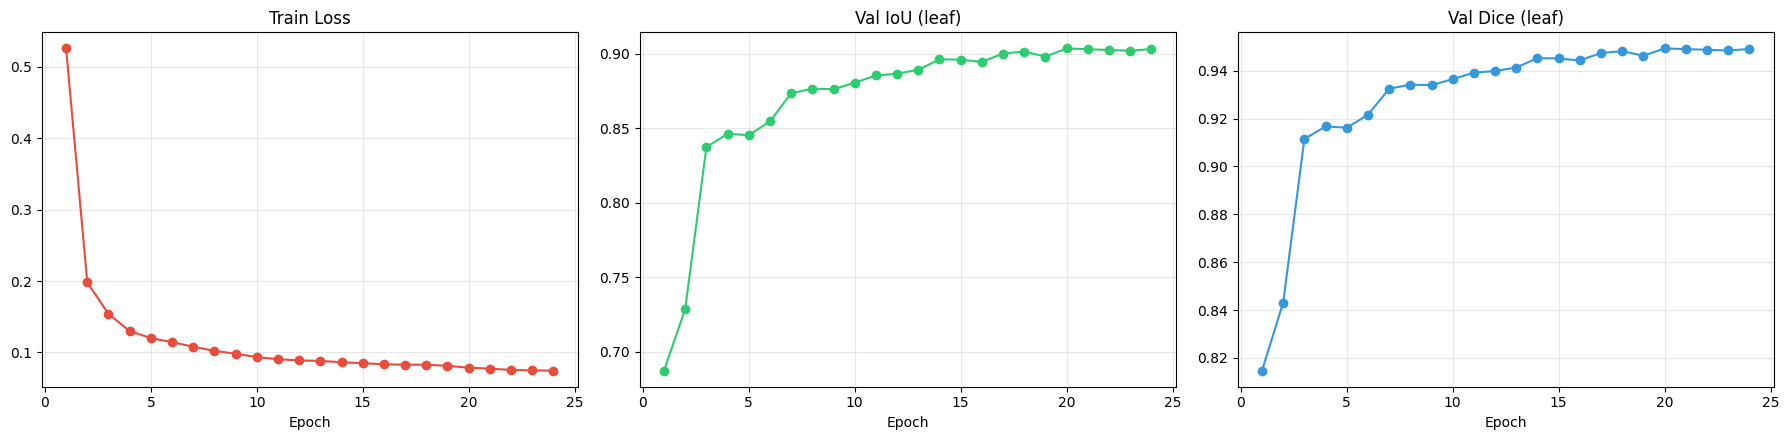

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(history['epoch'], history['train_loss'], 'o-', color='#E74C3C')
axes[0].set_title('Train Loss')
axes[1].plot(history['epoch'], history['val_iou'], 'o-', color='#2ECC71')
axes[1].set_title('Val IoU (leaf)')
axes[2].plot(history['epoch'], history['val_dice'], 'o-', color='#3498DB')
axes[2].set_title('Val Dice (leaf)')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluasi Test Set

Muat checkpoint terbaik (dipilih dari validation) lalu evaluasi **sekali**
di test set. Metrik utama: IoU, Dice, Precision, Recall foreground (leaf).

In [13]:
best_path = exp_dir / 'checkpoint_best.pth.tar'
assert best_path.exists(), 'Checkpoint best tidak ditemukan.'

ck = load_checkpoint(best_path, device)
model.load_state_dict(ck['state_dict'])
print(f"Checkpoint terbaik: epoch {ck['epoch']} | Dice val: {ck['best_pred']:.4f}")

test_metrics = evaluate(test_loader)
print('Hasil TEST SET:')
for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

cm = evaluator.confusion_matrix
print('Confusion matrix (baris=target, kolom=pred):')
print(cm)

Checkpoint terbaik: epoch 14 | Dice val: 0.9452
Hasil TEST SET:
  loss: 0.1958
  Acc: 0.9741
  mIoU: 0.9345
  IoU_leaf: 0.9031
  Dice_leaf: 0.9491
  Precision: 0.9369
  Recall: 0.9616
Confusion matrix (baris=target, kolom=pred):
[[2497349.   55346.]
 [  32854.  822323.]]


## 8. Visualisasi Prediksi

Per gambar test: asli, ground-truth biner, peta probabilitas daun, mask
prediksi, dan overlay error (kuning = false positive, biru = false negative).

Logika probabilitas di sini identik dengan `Predictor.predict_probability`
(spot-check jalur ensemble).

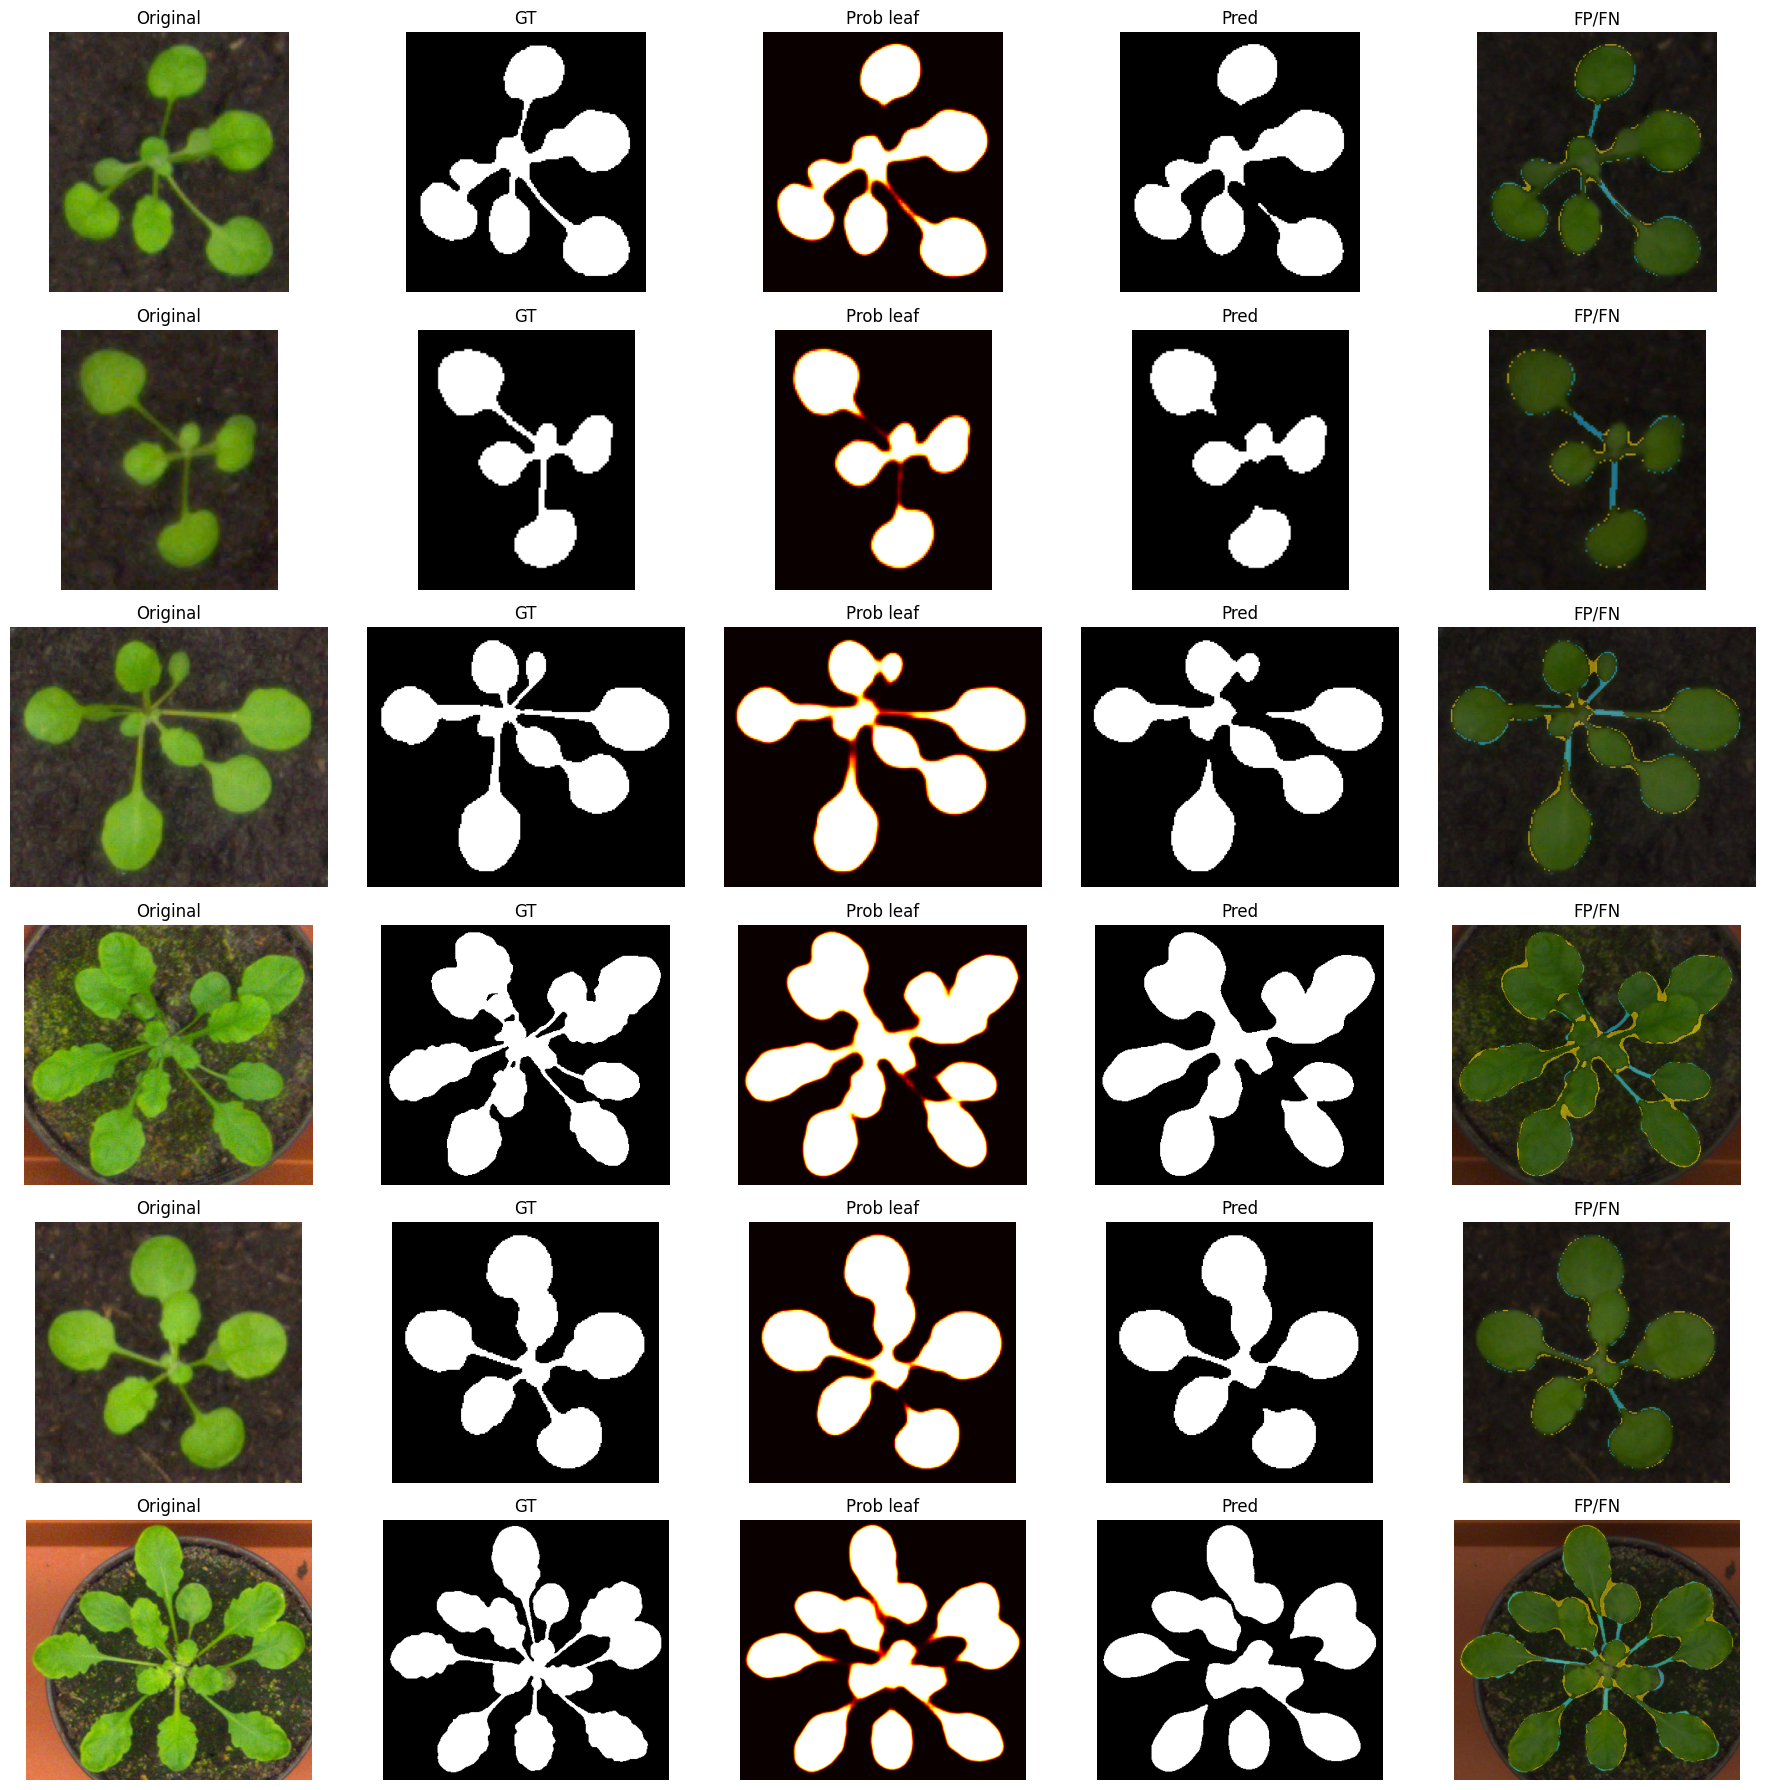

In [14]:
import torchvision.transforms as Ttf
from data_generators.data_generator import load_split_names

THRESH = 0.5
test_stems = load_split_names(Path('splits'), 'test')

prep = Ttf.Compose([
    Ttf.Resize((CROP_SIZE, CROP_SIZE), interpolation=Ttf.InterpolationMode.BICUBIC),
    Ttf.ToTensor(),
    Ttf.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])


def leaf_probability(pil_img):
    ow, oh = pil_img.size
    x = prep(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
    prob = F.softmax(logits, dim=1)[0, 1].cpu().numpy()
    return np.asarray(
        Image.fromarray(prob.astype(np.float32)).resize((ow, oh), Image.BILINEAR),
        dtype=np.float32)


def gt_binary(stem):
    m = np.asarray(Image.open(Path('data/masks') / f'{stem}.png'))
    if m.ndim == 3:
        m = np.any(m != 0, axis=2)
    return (m != 0).astype(np.uint8)


show = test_stems[:6]
fig, axes = plt.subplots(len(show), 5, figsize=(18, 3 * len(show)))
axes = np.atleast_2d(axes)

for r, stem in enumerate(show):
    pil = Image.open(Path('data/imgs') / f'{stem}.png').convert('RGB')
    img = np.asarray(pil)
    gt = gt_binary(stem)
    prob = leaf_probability(pil)
    pred = (prob >= THRESH).astype(np.uint8)
    fp = (pred == 1) & (gt == 0)
    fn = (pred == 0) & (gt == 1)

    err = np.zeros((*gt.shape, 3), dtype=np.uint8)
    err[fp] = [255, 200, 0]
    err[fn] = [0, 150, 255]

    titles = ['Original', 'GT', 'Prob leaf', 'Pred', 'FP/FN']
    panels = [img, gt, prob, pred, None]
    for c in range(5):
        ax = axes[r, c]
        if c == 4:
            ax.imshow(img)
            ax.imshow(err, alpha=0.5)
        elif c == 2:
            ax.imshow(prob, cmap='hot', vmin=0, vmax=1)
        elif c in (1, 3):
            ax.imshow(panels[c], cmap='gray', vmin=0, vmax=1)
        else:
            ax.imshow(panels[c])
        ax.set_title(titles[c])
        ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Ekspor Artefak untuk Ensemble

Semua diekspor ke `ensemble_ready/<experiment>/`:

| File | Isi |
|---|---|
| `checkpoint_best.pth.tar` | checkpoint terbaik (format `Saver`) |
| `config.yml` | konfigurasi eksperimen |
| `test_metrics.json` | metrik test set |
| `test_probs/*.npy` | probabilitas daun full-res, float32 `[0,1]` |
| `test_masks/*.png` | mask biner `threshold = 0.5` |
| `summary.json` | ringkasan lengkap |

Probabilitas dihitung lewat `Predictor.predict_probability` (softmax channel 1,
resize bilinear ke ukuran asli) sehingga langsung kompatibel dengan
`ensemble/fuse_predictions.py` saat digabung dengan U-Net.

In [24]:
# import json, shutil, importlib, torch
from pathlib import Path
import numpy as np
from PIL import Image
import importlib
import predictors.predictor as pp
importlib.reload(pp)
Predictor = pp.Predictor

out_dir = Path('ensemble_ready') / EXPERIMENT_NAME
prob_dir = out_dir / 'test_probs'
mask_dir = out_dir / 'test_masks'
prob_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(exist_ok=True)

# Salin config
shutil.copy(cfg_out, out_dir / 'config.yml')

# Salin checkpoint terbaik (predictor sudah menangani prefix 'module.' sendiri)
compatible_best_path = out_dir / 'checkpoint_best.pth.tar'
shutil.copy(best_path, compatible_best_path)

# Simpan metrics
with open(out_dir / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2, default=str)

# Prediksi probabilitas & mask untuk test set
predictor = Predictor(config, checkpoint_path=str(compatible_best_path))
for stem in test_stems:
    img_path = Path('data/imgs') / f'{stem}.png'
    prob = predictor.predict_probability(str(img_path))
    assert prob.dtype == np.float32 and prob.min() >= 0.0 and prob.max() <= 1.0
    np.save(prob_dir / f'{stem}.npy', prob)
    Image.fromarray((prob >= THRESH).astype(np.uint8)).save(mask_dir / f'{stem}.png')

# Ringkasan eksperimen
summary = {
    'experiment': EXPERIMENT_NAME,
    'seed': SEED,
    'split': {n: len(load_split_names(Path('splits'), n)) for n in ('train', 'val', 'test')},
    'model': {'arch': 'DeepLabV3+', 'backbone': BACKBONE, 'num_classes': NUM_CLASSES,
              'crop': CROP_SIZE, 'out_stride': 16},
    'training': {'epochs_run': len(history['epoch']), 'batch_size': BATCH_SIZE,
                 'loss': LOSS_TYPE, 'lr': LR, 'optimizer': 'SGD',
                 'momentum': MOMENTUM, 'weight_decay': WEIGHT_DECAY,
                 'lr_scheduler': 'poly', 'balanced_weights': BALANCED_WEIGHTS,
                 'freeze_bn': FREEZE_BN},
    'best_val_dice': best_dice,
    'test_metrics': test_metrics,
}
with open(out_dir / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Artefak ensemble:', out_dir.resolve())
print('Folder ini sementara di runtime; unduh bila ingin disimpan.')

Artefak ensemble: /content/deeplabV3-PyTorch/ensemble_ready/binary-256-resnet-cedice-e50
Folder ini sementara di runtime; unduh bila ingin disimpan.


In [21]:
# import json, shutil, torch
# from pathlib import Path
# from predictors.predictor import Predictor
# import numpy as np
# from PIL import Image

# out_dir = Path('ensemble_ready') / EXPERIMENT_NAME
# prob_dir = out_dir / 'test_probs'
# mask_dir = out_dir / 'test_masks'
# prob_dir.mkdir(parents=True, exist_ok=True)
# mask_dir.mkdir(exist_ok=True)

# # Salin config
# shutil.copy(cfg_out, out_dir / 'config.yml')

# # Load checkpoint dan pastikan prefix 'module.'
# checkpoint = torch.load(best_path, map_location=device, weights_only=False)
# state_dict = checkpoint.get('state_dict', checkpoint)
# new_state_dict = {}
# for k, v in state_dict.items():
#     if not k.startswith('module.'):
#         new_state_dict[f'module.{k}'] = v
#     else:
#         new_state_dict[k] = v
# checkpoint['state_dict'] = new_state_dict

# # Simpan versi kompatibel langsung ke out_dir
# compatible_best_path = out_dir / 'checkpoint_best.pth.tar'
# torch.save(checkpoint, compatible_best_path)

# # Simpan metrics
# with open(out_dir / 'test_metrics.json', 'w') as f:
#     json.dump(test_metrics, f, indent=2, default=str)

# # Gunakan checkpoint yang sudah kompatibel
# predictor = Predictor(config, checkpoint_path=str(compatible_best_path))
# for stem in test_stems:
#     img_path = Path('data/imgs') / f'{stem}.png'
#     prob = predictor.predict_probability(str(img_path))
#     assert prob.dtype == np.float32 and prob.min() >= 0.0 and prob.max() <= 1.0
#     np.save(prob_dir / f'{stem}.npy', prob)
#     Image.fromarray((prob >= THRESH).astype(np.uint8)).save(mask_dir / f'{stem}.png')

# # Ringkasan eksperimen
# summary = {
#     'experiment': EXPERIMENT_NAME,
#     'seed': SEED,
#     'split': {n: len(load_split_names(Path('splits'), n)) for n in ('train', 'val', 'test')},
#     'model': {'arch': 'DeepLabV3+', 'backbone': BACKBONE, 'num_classes': NUM_CLASSES,
#               'crop': CROP_SIZE, 'out_stride': 16},
#     'training': {'epochs_run': len(history['epoch']), 'batch_size': BATCH_SIZE,
#                  'loss': LOSS_TYPE, 'lr': LR, 'optimizer': 'SGD',
#                  'momentum': MOMENTUM, 'weight_decay': WEIGHT_DECAY,
#                  'lr_scheduler': 'poly', 'balanced_weights': BALANCED_WEIGHTS,
#                  'freeze_bn': FREEZE_BN},
#     'best_val_dice': best_dice,
#     'test_metrics': test_metrics,
# }
# with open(out_dir / 'summary.json', 'w') as f:
#     json.dump(summary, f, indent=2, default=str)

# print('Artefak ensemble:', out_dir.resolve())
# print('Folder ini sementara di runtime; unduh bila ingin disimpan.')


In [19]:
# import json, shutil
# from predictors.predictor import Predictor

# out_dir = Path('ensemble_ready') / EXPERIMENT_NAME
# prob_dir = out_dir / 'test_probs'
# mask_dir = out_dir / 'test_masks'
# prob_dir.mkdir(parents=True, exist_ok=True)
# mask_dir.mkdir(exist_ok=True)

# # Salin config
# shutil.copy(cfg_out, out_dir / 'config.yml')

# # Memuat ulang secara bersih dari best_path
# clean_checkpoint = torch.load(best_path, map_location=device, weights_only=False)
# state_dict = clean_checkpoint['state_dict']
# new_state_dict = {}
# for k, v in state_dict.items():
#     if k.startswith('module.'):
#         new_state_dict[k] = v
#     else:
#         new_state_dict[f'module.{k}'] = v
# clean_checkpoint['state_dict'] = new_state_dict

# # Simpan versi yang kompatibel
# compatible_best_path = exp_dir / 'checkpoint_best_compatible.pth.tar'
# torch.save(clean_checkpoint, compatible_best_path)
# shutil.copy(compatible_best_path, out_dir / 'checkpoint_best.pth.tar')

# with open(out_dir / 'test_metrics.json', 'w') as f:
#     json.dump(test_metrics, f, indent=2, default=str)

# # Gunakan checkpoint yang sudah kompatibel
# predictor = Predictor(config, checkpoint_path=str(compatible_best_path))
# for stem in test_stems:
#     img_path = Path('data/imgs') / f'{stem}.png'
#     prob = predictor.predict_probability(str(img_path))
#     assert prob.dtype == np.float32 and prob.min() >= 0.0 and prob.max() <= 1.0
#     np.save(prob_dir / f'{stem}.npy', prob)
#     Image.fromarray((prob >= THRESH).astype(np.uint8)).save(mask_dir / f'{stem}.png')

# summary = {
#     'experiment': EXPERIMENT_NAME,
#     'seed': SEED,
#     'split': {n: len(load_split_names(Path('splits'), n)) for n in ('train', 'val', 'test')},
#     'model': {'arch': 'DeepLabV3+', 'backbone': BACKBONE, 'num_classes': NUM_CLASSES,
#               'crop': CROP_SIZE, 'out_stride': 16},
#     'training': {'epochs_run': len(history['epoch']), 'batch_size': BATCH_SIZE,
#                  'loss': LOSS_TYPE, 'lr': LR, 'optimizer': 'SGD',
#                  'momentum': MOMENTUM, 'weight_decay': WEIGHT_DECAY,
#                  'lr_scheduler': 'poly', 'balanced_weights': BALANCED_WEIGHTS,
#                  'freeze_bn': FREEZE_BN},
#     'best_val_dice': best_dice,
#     'test_metrics': test_metrics,
# }
# with open(out_dir / 'summary.json', 'w') as f:
#     json.dump(summary, f, indent=2, default=str)

# print('Artefak ensemble:', out_dir.resolve())
# print('Folder ini sementara di runtime; unduh bila ingin disimpan.')

RuntimeError: Error(s) in loading state_dict for DataParallel:
	Missing key(s) in state_dict: "module.backbone.conv1.weight", "module.backbone.bn1.weight", "module.backbone.bn1.bias", "module.backbone.bn1.running_mean", "module.backbone.bn1.running_var", "module.backbone.layer1.0.conv1.weight", "module.backbone.layer1.0.bn1.weight", "module.backbone.layer1.0.bn1.bias", "module.backbone.layer1.0.bn1.running_mean", "module.backbone.layer1.0.bn1.running_var", "module.backbone.layer1.0.conv2.weight", "module.backbone.layer1.0.bn2.weight", "module.backbone.layer1.0.bn2.bias", "module.backbone.layer1.0.bn2.running_mean", "module.backbone.layer1.0.bn2.running_var", "module.backbone.layer1.0.conv3.weight", "module.backbone.layer1.0.bn3.weight", "module.backbone.layer1.0.bn3.bias", "module.backbone.layer1.0.bn3.running_mean", "module.backbone.layer1.0.bn3.running_var", "module.backbone.layer1.0.downsample.0.weight", "module.backbone.layer1.0.downsample.1.weight", "module.backbone.layer1.0.downs

## 10. Ringkasan Protokol Eksperimen

In [ ]:
counts = {n: len(load_split_names(Path('splits'), n)) for n in ('train', 'val', 'test')}
tm = test_metrics
print('=' * 62)
print('PROTOKOL EKSPERIMEN - DeepLabV3 saja')
print('=' * 62)
print(f'experiment_id    : {EXPERIMENT_NAME}')
print(f'dataset          : plant_phenotyping (binary leaf)')
print(f'split            : {counts}')
print(f'seed             : {SEED}')
print(f'arsitektur       : DeepLabV3+ {BACKBONE} os=16')
print(f'image_size       : {CROP_SIZE} x {CROP_SIZE}')
print(f'loss             : {LOSS_TYPE} (balanced_weights={BALANCED_WEIGHTS})')
print(f'optimizer        : SGD lr={LR} momentum={MOMENTUM} wd={WEIGHT_DECAY} poly')
print(f'epochs_run       : {len(history["epoch"])} (patience={PATIENCE})')
print(f'batch_size       : {BATCH_SIZE}')
print('-' * 62)
print(f'best val Dice    : {best_dice:.4f}')
print(f'test IoU         : {tm["IoU_leaf"]:.4f}')
print(f'test Dice        : {tm["Dice_leaf"]:.4f}')
print(f'test Precision   : {tm["Precision"]:.4f}')
print(f'test Recall      : {tm["Recall"]:.4f}')
print('=' * 62)

## 11. TensorBoard (Opsional)

In [ ]:
if IN_COLAB:
    %load_ext tensorboard
    %tensorboard --logdir ./tensorboard
else:
    print('Jalankan di terminal: tensorboard --logdir ./tensorboard')

## Langkah Berikutnya: Ensemble dengan U-Net

Urutan eksperimen minimum (sesuai `docs/ensembel.md`):

1. **U-Net saja** - sudah selesai di notebook referensi.
2. **DeepLabV3 saja** - selesai di notebook ini.
3. Ensemble `alpha=0.5`, `threshold=0.5`.
4. Ensemble dengan `alpha`/`threshold` terbaik dari **validation set**.

Penggabungan memakai probabilitas foreground kedua model:

```python
ensemble_prob = alpha * unet_prob + (1 - alpha) * deeplab_prob
ensemble_mask = ensemble_prob >= threshold
```

Di notebook U-Net, sediakan fungsi probabilitas lalu panggil modul ensemble:

```python
from ensemble.fuse_predictions import EnsembleFusion, search_alpha_threshold, evaluate_masks

def unet_prob_fn(image_path):
    # softmax(unet_logits, dim=1)[0, 1], resize bilinear ke ukuran asli
    ...

deeplab_ckpt = 'ensemble_ready/<experiment>/checkpoint_best.pth.tar'
best = search_alpha_threshold(config, deeplab_ckpt, unet_prob_fn,
                              split_dir=Path('splits'), data_dir=Path('data'))
# evaluasi final satu kali di test set dengan alpha/threshold terbaik
```

Aturan validitas: ensemble dinyatakan lebih baik hanya jika metrik **test set**
(IoU/Dice foreground) meningkat dibanding kedua model tunggal. `alpha` dan
`threshold` tidak boleh dicari dari test set.